In [ ]:
import numpy as np
from scipy.signal import savgol_filter
from scipy.sparse import csc_matrix, eye, diags
from scipy.sparse.linalg import spsolve

# ---- MSC----
def msc(X):
        mean_spectrum = np.mean(X, axis=0)
        corrected_X = np.zeros_like(X)
        for i in range(X.shape[0]):
            p = np.polyfit(mean_spectrum, X[i, :], 1)
            corrected_X[i, :] = (X[i, :] - p[1]) / p[0]
        return corrected_X

# ---- SNV----
def snv(X):
    return (X - np.mean(X, axis=1)[:, np.newaxis]) / np.std(X, axis=1)[:, np.newaxis]
        
# ---- Savitzky-Golay----
def savitzky_golay(X, window_length=11, polyorder=2, deriv=0, axis=1):
    return savgol_filter(X, window_length=window_length, polyorder=polyorder, deriv=deriv, axis=axis)

# ---- SG-2D----
def savitzky_golay(X, window_length=11, polyorder=2, deriv=2, axis=1):
    return savgol_filter(X, window_length=window_length, polyorder=polyorder, deriv=deriv, axis=axis)

# ---- airPLS----
def _whittaker_1d(x, w, lam, differences=1):
    x = np.asarray(x, dtype=float).ravel()
    m = x.size
    E = eye(m, format='csc')
    for _ in range(differences):
        E = E[1:] - E[:-1]
    W = diags(w, 0, shape=(m, m))
    A = csc_matrix(W + lam * E.T * E)
    B = csc_matrix(W * x.reshape(-1, 1))
    z = spsolve(A, B)
    return np.asarray(z).ravel()

def airPLS(X, lam=100, porder=1, itermax=15):
    X = np.asarray(X, dtype=float)
    n_samples = X.shape[0]
    X_corr = np.empty_like(X)
    for i in range(n_samples):
        x = X[i].ravel()
        w = np.ones(x.size)
        z = np.zeros_like(x)
        for it in range(1, itermax + 1):
            z = _whittaker_1d(x, w, lam, porder)
            d = x - z
            neg = d < 0
            dssn = np.abs(d[neg].sum())
            if dssn == 0:
                break
            w[~neg] = 0
            w[neg] = np.exp(it * np.abs(d[neg]) / dssn)
            w[0] = w[-1] = np.exp(it * (d[neg].max()) / dssn)
        X_corr[i, :] = x - z
    return X_corr

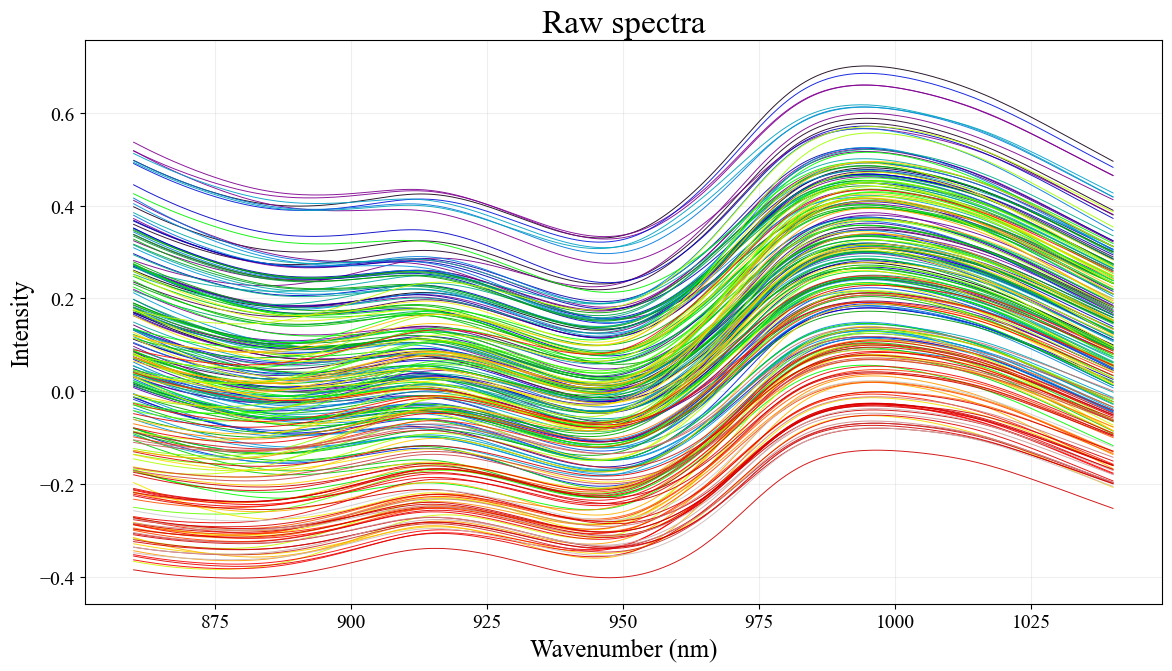

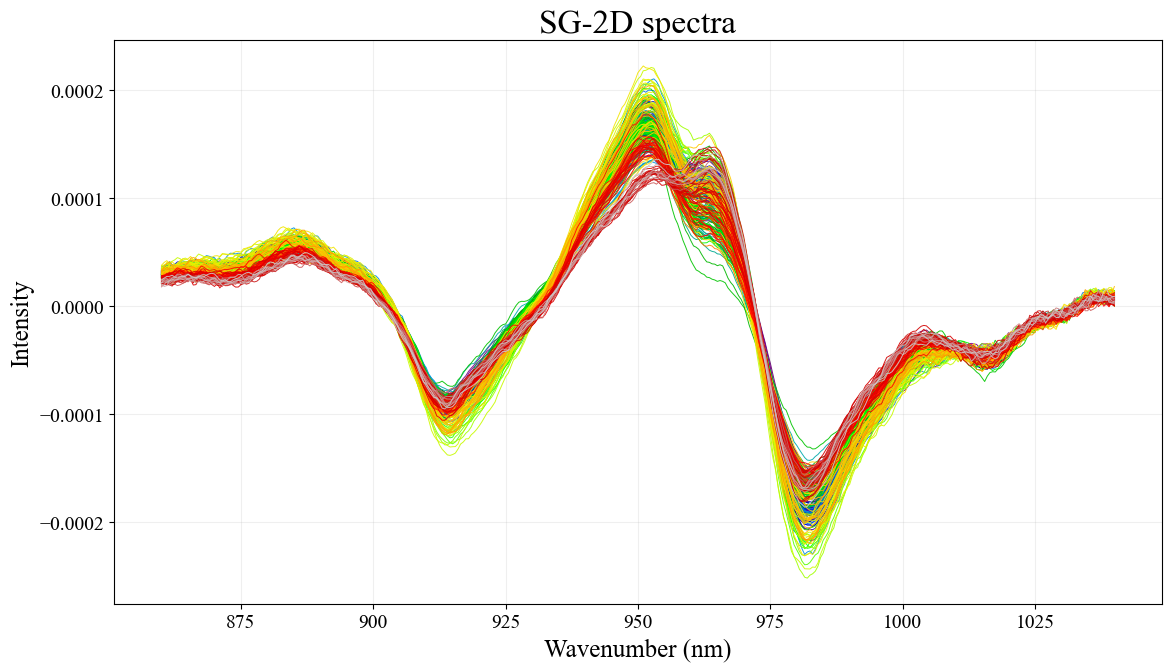

Raw shape: (248, 361), SG-2D shape: (248, 361)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file_path = r"D:\A\CSU\NIRdatasets\wheat\A3_processed.xlsx"

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 16,
    'axes.titlesize': 24,
    'axes.labelsize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
})

raw_df = pd.read_excel(file_path, sheet_name="Raw")
sg2d_df = pd.read_excel(file_path, sheet_name="SG-2D")


wavenumbers = raw_df.columns[1:-1].astype(float).to_numpy()
X_raw = raw_df.iloc[:, 1:-1].to_numpy(dtype=float)
X_sg2d = sg2d_df.iloc[:, 1:-1].to_numpy(dtype=float)

mask = (wavenumbers >= 860) & (wavenumbers <= 1040)
w = wavenumbers[mask]
X_raw = X_raw[:, mask]
X_sg2d = X_sg2d[:, mask]


N_raw = X_raw.shape[0]
N_sg = X_sg2d.shape[0]
cmap = plt.get_cmap('nipy_spectral')
colors_raw = cmap(np.linspace(0, 1, N_raw))
colors_sg = cmap(np.linspace(0, 1, N_sg))

plt.figure(figsize=(12, 7))
for i, spec in enumerate(X_raw):
    plt.plot(w, spec, color=colors_raw[i], alpha=0.9, linewidth=0.7)
plt.title('Raw spectra', fontsize=24)
plt.xlabel('Wavenumber (nm)', fontsize=18)
plt.ylabel('Intensity', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 7))
for i, spec in enumerate(X_sg2d):
    plt.plot(w, spec, color=colors_sg[i], alpha=0.9, linewidth=0.7)
plt.title('SG-2D spectra', fontsize=24)
plt.xlabel('Wavenumber (nm)', fontsize=18)
plt.ylabel('Intensity', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Raw shape: {X_raw.shape}, SG-2D shape: {X_sg2d.shape}")